our proposed method is quality-aware, so we evaluated it on quality-defined subsets.

Not random degradation.

That directly matches our method.
The proposed method improves neural gated fusion and prevents collapse under quality-variable conditions.
This proves our model behaves intelligently.

Meta RF/XGB cannot explain modality contribution like this.

So our proposed method stands out in:

interpretability + adaptive behavior

not only raw accuracy.

# Cell 1 — Setup + load saved arrays

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ROOT = "/content/drive/MyDrive/xenocanto"
OUT_DIR = os.path.join(ROOT, "outputs_thesis_full")

CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
EMB_DIR = os.path.join(OUT_DIR, "embeddings")
META_DIR = os.path.join(OUT_DIR, "meta_models")
REPORT_DIR = os.path.join(OUT_DIR, "reports")

OUT_Q_DIR = os.path.join(REPORT_DIR, "natural_quality_subset_evaluation")
os.makedirs(OUT_Q_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# Saved features/logits
img_te_f = np.load(os.path.join(EMB_DIR, "img_te_feat.npy"))
img_te_l = np.load(os.path.join(EMB_DIR, "img_te_logits.npy"))

aud_te_f = np.load(os.path.join(EMB_DIR, "ast_te_feat.npy"))
aud_te_l = np.load(os.path.join(EMB_DIR, "ast_te_logits.npy"))

y_te = np.load(os.path.join(EMB_DIR, "y_te.npy")).astype(int)

# Quality values
Q_te = np.load(os.path.join(REPORT_DIR, "Q_test.npy"))
Q_mu = np.load(os.path.join(REPORT_DIR, "Q_mu.npy"))
Q_sd = np.load(os.path.join(REPORT_DIR, "Q_sd.npy"))

def norm_q(Q):
    return (Q - Q_mu) / Q_sd

Q_te_n = norm_q(Q_te)

print("img_te_f:", img_te_f.shape)
print("aud_te_f:", aud_te_f.shape)
print("Q_te:", Q_te.shape)
print("y_te:", y_te.shape)

# Cell 2 — Model classes + helpers

In [ ]:
class EarlyFusionMLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class GatedFusion(nn.Module):
    def __init__(self, img_dim, aud_dim, num_classes, hidden=512):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, hidden)
        self.aud_proj = nn.Linear(aud_dim, hidden)
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.out = nn.Linear(hidden, num_classes)

    def forward(self, x, Xa=None):
        hi = F.relu(self.img_proj(x))
        ha = F.relu(self.aud_proj(Xa))
        g = torch.sigmoid(self.gate(torch.cat([hi, ha], dim=1)))
        return self.out(g * hi + (1 - g) * ha), g


class GatedFusionBalanced(nn.Module):
    def __init__(self, img_dim, aud_dim, num_classes, hidden=512, dropout=0.3):
        super().__init__()
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.aud_proj = nn.Sequential(
            nn.Linear(aud_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )
        self.out = nn.Linear(hidden, num_classes)

    def forward(self, x, Xa=None):
        hi = self.img_proj(x)
        ha = self.aud_proj(Xa)
        g = torch.sigmoid(self.gate(torch.cat([hi, ha], dim=1)))
        return self.out(g * hi + (1 - g) * ha), g


class QualityAwareGatedFusion(nn.Module):
    def __init__(self, img_dim, aud_dim, q_dim, num_classes, hidden=512):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, hidden)
        self.aud_proj = nn.Linear(aud_dim, hidden)
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2 + q_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.out = nn.Linear(hidden, num_classes)

    def forward(self, x, Xa=None, Xq=None):
        hi = F.relu(self.img_proj(x))
        ha = F.relu(self.aud_proj(Xa))
        g = torch.sigmoid(self.gate(torch.cat([hi, ha, Xq], dim=1)))
        return self.out(g * hi + (1 - g) * ha), g


class QualityAwareGatedFusionBalanced(nn.Module):
    def __init__(self, img_dim, aud_dim, q_dim, num_classes, hidden=512, dropout=0.3):
        super().__init__()
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.aud_proj = nn.Sequential(
            nn.Linear(aud_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2 + q_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )
        self.out = nn.Linear(hidden, num_classes)

    def forward(self, x, Xa=None, Xq=None):
        hi = self.img_proj(x)
        ha = self.aud_proj(Xa)
        g = torch.sigmoid(self.gate(torch.cat([hi, ha, Xq], dim=1)))
        return self.out(g * hi + (1 - g) * ha), g


def softmax_np(logits):
    z = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / (e.sum(axis=1, keepdims=True) + 1e-12)


@torch.no_grad()
def mlp_logits(model, X, batch=256):
    model.eval()
    outs = []
    for i in range(0, len(X), batch):
        xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=DEVICE)
        out = model(xb)
        if isinstance(out, tuple):
            out = out[0]
        outs.append(out.cpu().numpy())
    return np.concatenate(outs, axis=0)


@torch.no_grad()
def gated_logits(model, Xi, Xa, Xq=None, batch=256):
    model.eval()
    logits_all, gates_all = [], []

    for i in range(0, len(Xi), batch):
        xi = torch.tensor(Xi[i:i+batch], dtype=torch.float32, device=DEVICE)
        xa = torch.tensor(Xa[i:i+batch], dtype=torch.float32, device=DEVICE)

        if Xq is None:
            logits, g = model(xi, Xa=xa)
        else:
            xq = torch.tensor(Xq[i:i+batch], dtype=torch.float32, device=DEVICE)
            logits, g = model(xi, Xa=xa, Xq=xq)

        logits_all.append(logits.cpu().numpy())
        gates_all.append(g.squeeze(1).cpu().numpy())

    return np.concatenate(logits_all), np.concatenate(gates_all)

# Cell 3 — Load saved fusion models

In [ ]:
# Early fusion
ck = torch.load(os.path.join(CKPT_DIR, "fusion_early_imgemb_astemb_mlp_best.pt"), map_location=DEVICE)
early_model = EarlyFusionMLP(ck["in_dim"], ck["num_classes"]).to(DEVICE)
early_model.load_state_dict(ck["state_dict"])
early_model.eval()

# Original gated
ck = torch.load(os.path.join(CKPT_DIR, "fusion_gated_img_ast_best.pt"), map_location=DEVICE)
gate_model = GatedFusion(ck["img_dim"], ck["aud_dim"], ck["num_classes"]).to(DEVICE)
gate_model.load_state_dict(ck["state_dict"])
gate_model.eval()

# Balanced gated
ck = torch.load(os.path.join(CKPT_DIR, "fusion_gated_balanced_img_ast_best.pt"), map_location=DEVICE)
bal_gate_model = GatedFusionBalanced(
    ck["img_dim"], ck["aud_dim"], ck["num_classes"],
    hidden=512, dropout=0.3
).to(DEVICE)
bal_gate_model.load_state_dict(ck["state_dict"])
bal_gate_model.eval()

# Quality-aware gated
ck = torch.load(os.path.join(CKPT_DIR, "fusion_quality_aware_gated_img_ast_best.pt"), map_location=DEVICE)
qa_model = QualityAwareGatedFusion(
    ck["img_dim"], ck["aud_dim"], ck["q_dim"], ck["num_classes"]
).to(DEVICE)
qa_model.load_state_dict(ck["state_dict"])
qa_model.eval()

# Quality-aware balanced gated
ck = torch.load(os.path.join(CKPT_DIR, "fusion_qualityaware_balanced_img_ast_best.pt"), map_location=DEVICE)
qa_bal_model = QualityAwareGatedFusionBalanced(
    ck["img_dim"], ck["aud_dim"], ck["q_dim"], ck["num_classes"],
    hidden=512, dropout=0.3
).to(DEVICE)
qa_bal_model.load_state_dict(ck["state_dict"])
qa_bal_model.eval()

# Classical models
emb_logreg = joblib.load(os.path.join(META_DIR, "embedding_fusion_logreg_img_ast.joblib"))

meta_models = {}
for name in ["LogReg", "SVM_RBF", "RandomForest", "XGBoost"]:
    p = os.path.join(META_DIR, f"meta_{name}_img_ast.joblib")
    meta_models[name] = joblib.load(p)

print("All models loaded.")

All models loaded.


# Cell 4 — Define natural quality subsets

In [ ]:
img_q = Q_te[:, 0]
aud_q = Q_te[:, 1]

img_q25 = np.quantile(img_q, 0.25)
img_q50 = np.quantile(img_q, 0.50)
img_q75 = np.quantile(img_q, 0.75)

aud_q25 = np.quantile(aud_q, 0.25)
aud_q50 = np.quantile(aud_q, 0.50)
aud_q75 = np.quantile(aud_q, 0.75)

quality_subsets = {
    "All Test": np.arange(len(y_te)),

    "Low Image / Good Audio": np.where(
        (img_q <= img_q25) & (aud_q >= aud_q50)
    )[0],

    "Low Audio / Good Image": np.where(
        (aud_q <= aud_q25) & (img_q >= img_q50)
    )[0],

    "Both Low Quality": np.where(
        (img_q <= img_q25) & (aud_q <= aud_q25)
    )[0],

    "Both High Quality": np.where(
        (img_q >= img_q75) & (aud_q >= aud_q75)
    )[0],

    "Low Image Only": np.where(img_q <= img_q25)[0],

    "Low Audio Only": np.where(aud_q <= aud_q25)[0],
}

subset_info = pd.DataFrame([
    {
        "Subset": name,
        "N": len(idx),
        "MeanImageQuality": float(img_q[idx].mean()) if len(idx) else np.nan,
        "MeanAudioQuality": float(aud_q[idx].mean()) if len(idx) else np.nan,
    }
    for name, idx in quality_subsets.items()
])

display(subset_info)

subset_info.to_csv(
    os.path.join(OUT_Q_DIR, "natural_quality_subset_counts.csv"),
    index=False
)


,Subset,N,MeanImageQuality,MeanAudioQuality
0,All Test,459,0.043917,0.490223
1,Low Image / Good Audio,56,0.007040,0.653722
2,Low Audio / Good Image,59,0.074820,0.268166
3,Both Low Quality,32,0.007327,0.274356
4,Both High Quality,31,0.117550,0.752912
5,Low Image Only,115,0.007223,0.484161
6,Low Audio Only,115,0.044432,0.266037


# Cell 5 — Evaluate all systems on each subset

In [ ]:
# Precompute full-test predictions once

img_pred = img_te_l.argmax(axis=1)
aud_pred = aud_te_l.argmax(axis=1)

img_p = softmax_np(img_te_l)
aud_p = softmax_np(aud_te_l)

X_early = np.concatenate([img_te_f, aud_te_f], axis=1)
early_logits = mlp_logits(early_model, X_early)
early_pred = early_logits.argmax(axis=1)

emb_pred = emb_logreg.predict(X_early)

X_meta = np.concatenate(
    [img_te_f, aud_te_f, img_te_l, aud_te_l, img_p, aud_p],
    axis=1
)

meta_preds = {}
for name, clf in meta_models.items():
    meta_preds[name] = clf.predict(X_meta)

gate_logits, gate_alpha = gated_logits(gate_model, img_te_f, aud_te_f)
gate_pred = gate_logits.argmax(axis=1)

bal_gate_logits, bal_gate_alpha = gated_logits(bal_gate_model, img_te_f, aud_te_f)
bal_gate_pred = bal_gate_logits.argmax(axis=1)

qa_logits, qa_alpha = gated_logits(qa_model, img_te_f, aud_te_f, Xq=Q_te_n)
qa_pred = qa_logits.argmax(axis=1)

qa_bal_logits, qa_bal_alpha = gated_logits(qa_bal_model, img_te_f, aud_te_f, Xq=Q_te_n)
qa_bal_pred = qa_bal_logits.argmax(axis=1)

rows = []

def add_result(subset_name, idx, system, pred, gate=None):
    if len(idx) == 0:
        return
    rows.append({
        "Subset": subset_name,
        "N": len(idx),
        "System": system,
        "Accuracy": float(accuracy_score(y_te[idx], pred[idx])),
        "MeanGateAlpha": float(np.mean(gate[idx])) if gate is not None else np.nan,
        "MeanImageQuality": float(np.mean(img_q[idx])),
        "MeanAudioQuality": float(np.mean(aud_q[idx])),
    })

for subset_name, idx in quality_subsets.items():
    add_result(subset_name, idx, "Image Only (ConvNeXt)", img_pred)
    add_result(subset_name, idx, "Audio Only (AST-MLP)", aud_pred)
    add_result(subset_name, idx, "Fusion: Early MLP", early_pred)
    add_result(subset_name, idx, "Fusion: Embedding LogReg", emb_pred)

    for name, pred in meta_preds.items():
        add_result(subset_name, idx, f"Fusion: Meta {name}", pred)

    add_result(subset_name, idx, "Fusion: Gated", gate_pred, gate_alpha)
    add_result(subset_name, idx, "Fusion: Balanced Gated", bal_gate_pred, bal_gate_alpha)
    add_result(subset_name, idx, "Fusion: Quality-Aware Gated", qa_pred, qa_alpha)
    add_result(subset_name, idx, "Fusion: Quality-Aware Balanced Gated", qa_bal_pred, qa_bal_alpha)

quality_eval_df = pd.DataFrame(rows)

display(quality_eval_df)

quality_eval_df.to_csv(
    os.path.join(OUT_Q_DIR, "natural_quality_subset_all_models.csv"),
    index=False
)

,Subset,N,System,Accuracy,MeanGateAlpha,MeanImageQuality,MeanAudioQuality
0,All Test,459,Image Only (ConvNeXt),0.945534,NaN,0.043917,0.490223
1,All Test,459,Audio Only (AST-MLP),0.718954,NaN,0.043917,0.490223
2,All Test,459,Fusion: Early MLP,0.958606,NaN,0.043917,0.490223
3,All Test,459,Fusion: Embedding LogReg,0.958606,NaN,0.043917,0.490223
4,All Test,459,Fusion: Meta LogReg,0.978214,NaN,0.043917,0.490223
...,...,...,...,...,...,...,...
79,Low Audio Only,115,Fusion: Meta XGBoost,0.956522,NaN,0.044432,0.266037
80,Low Audio Only,115,Fusion: Gated,0.956522,1.000000,0.044432,0.266037
81,Low Audio Only,115,Fusion: Balanced Gated,0.973913,0.546079,0.044432,0.266037
82,Low Audio Only,115,Fusion: Quality-Aware Gated,0.947826,1.000000,0.044432,0.266037


# ## 🔍 Gate Behaviour Analysis (Quality-Aware Fusion)

In [ ]:
# Gate α vs modality quality
# α = image weight
# lower α means model relies more on audio
# higher α means model relies more on image

import numpy as np
import matplotlib.pyplot as plt
import os

# correlations
corr_img_qabal = np.corrcoef(img_q, qa_bal_alpha)[0, 1]
corr_aud_qabal = np.corrcoef(aud_q, qa_bal_alpha)[0, 1]

corr_img_qa = np.corrcoef(img_q, qa_alpha)[0, 1]
corr_aud_qa = np.corrcoef(aud_q, qa_alpha)[0, 1]

print("Quality-Aware Balanced Gated:")
print("corr(image quality, alpha):", corr_img_qabal)
print("corr(audio quality, alpha):", corr_aud_qabal)

print("\nOriginal Quality-Aware Gated:")
print("corr(image quality, alpha):", corr_img_qa)
print("corr(audio quality, alpha):", corr_aud_qa)

Quality-Aware Balanced Gated:
corr(image quality, alpha): -0.03638399083204855
corr(audio quality, alpha): 0.17455861730711977

Original Quality-Aware Gated:
corr(image quality, alpha): nan
corr(audio quality, alpha): nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


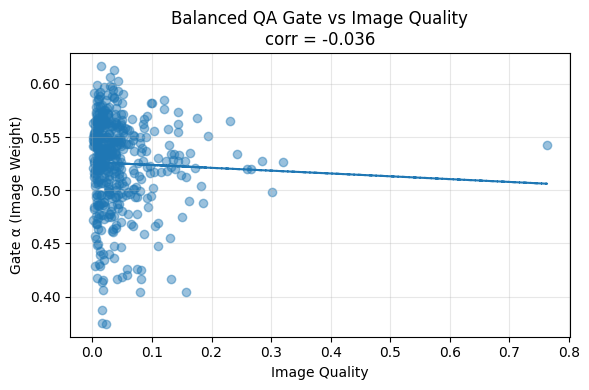

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/qabal_gate_vs_image_quality.png


In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(img_q, qa_bal_alpha, alpha=0.45)
m, b = np.polyfit(img_q, qa_bal_alpha, 1)
plt.plot(img_q, m * img_q + b, linestyle="--")

plt.xlabel("Image Quality")
plt.ylabel("Gate α (Image Weight)")
plt.title(f"Balanced QA Gate vs Image Quality\ncorr = {corr_img_qabal:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()

out = os.path.join(OUT_Q_DIR, "qabal_gate_vs_image_quality.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

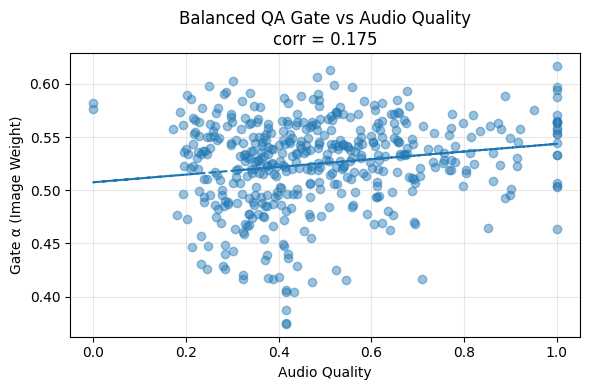

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/qabal_gate_vs_audio_quality.png


In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(aud_q, qa_bal_alpha, alpha=0.45)
m, b = np.polyfit(aud_q, qa_bal_alpha, 1)
plt.plot(aud_q, m * aud_q + b, linestyle="--")

plt.xlabel("Audio Quality")
plt.ylabel("Gate α (Image Weight)")
plt.title(f"Balanced QA Gate vs Audio Quality\ncorr = {corr_aud_qabal:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()

out = os.path.join(OUT_Q_DIR, "qabal_gate_vs_audio_quality.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

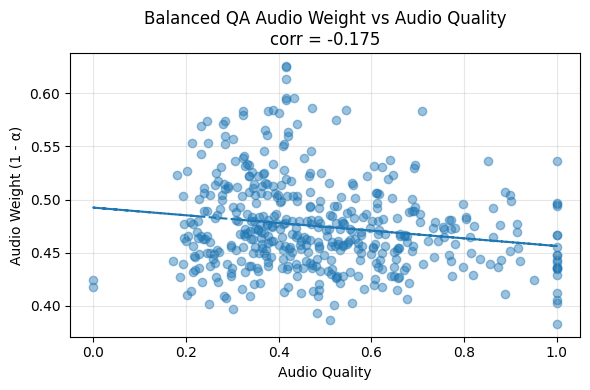

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/qabal_audio_weight_vs_audio_quality.png


In [ ]:
audio_weight = 1 - qa_bal_alpha
corr_audio_weight = np.corrcoef(aud_q, audio_weight)[0, 1]

plt.figure(figsize=(6, 4))

plt.scatter(aud_q, audio_weight, alpha=0.45)
m, b = np.polyfit(aud_q, audio_weight, 1)
plt.plot(aud_q, m * aud_q + b, linestyle="--")

plt.xlabel("Audio Quality")
plt.ylabel("Audio Weight (1 - α)")
plt.title(f"Balanced QA Audio Weight vs Audio Quality\ncorr = {corr_audio_weight:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()

out = os.path.join(OUT_Q_DIR, "qabal_audio_weight_vs_audio_quality.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

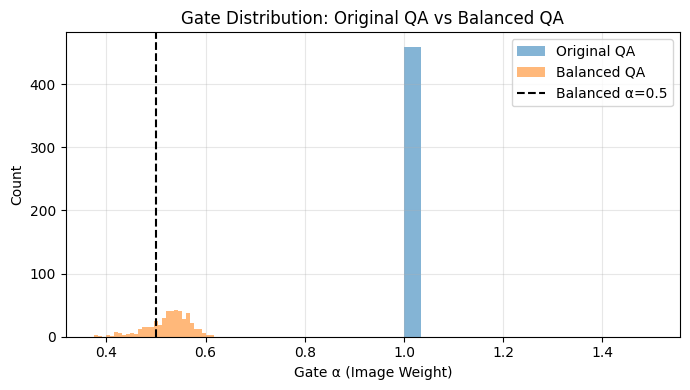

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/qa_vs_qabal_gate_distribution.png


In [ ]:
plt.figure(figsize=(7, 4))

plt.hist(qa_alpha, bins=30, alpha=0.55, label="Original QA")
plt.hist(qa_bal_alpha, bins=30, alpha=0.55, label="Balanced QA")
plt.axvline(0.5, linestyle="--", color="black", label="Balanced α=0.5")

plt.xlabel("Gate α (Image Weight)")
plt.ylabel("Count")
plt.title("Gate Distribution: Original QA vs Balanced QA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

out = os.path.join(OUT_Q_DIR, "qa_vs_qabal_gate_distribution.png")
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

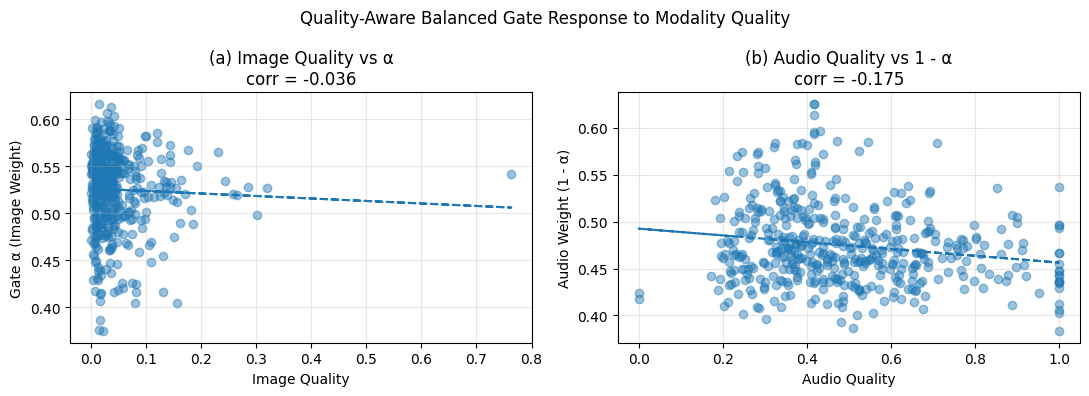

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/qabal_gate_quality_response_2panel.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: image quality vs image weight
axes[0].scatter(img_q, qa_bal_alpha, alpha=0.45)
m, b = np.polyfit(img_q, qa_bal_alpha, 1)
axes[0].plot(img_q, m * img_q + b, linestyle="--")
axes[0].set_xlabel("Image Quality")
axes[0].set_ylabel("Gate α (Image Weight)")
axes[0].set_title(f"(a) Image Quality vs α\ncorr = {corr_img_qabal:.3f}")
axes[0].grid(alpha=0.3)

# Panel B: audio quality vs audio weight
audio_weight = 1 - qa_bal_alpha
corr_audio_weight = np.corrcoef(aud_q, audio_weight)[0, 1]

axes[1].scatter(aud_q, audio_weight, alpha=0.45)
m, b = np.polyfit(aud_q, audio_weight, 1)
axes[1].plot(aud_q, m * aud_q + b, linestyle="--")
axes[1].set_xlabel("Audio Quality")
axes[1].set_ylabel("Audio Weight (1 - α)")
axes[1].set_title(f"(b) Audio Quality vs 1 - α\ncorr = {corr_audio_weight:.3f}")
axes[1].grid(alpha=0.3)

plt.suptitle("Quality-Aware Balanced Gate Response to Modality Quality")
plt.tight_layout()

out = os.path.join(OUT_Q_DIR, "qabal_gate_quality_response_2panel.png")
plt.savefig(out, dpi=250)
plt.show()

print("Saved:", out)

# Cell 6 — Accuracy table

In [ ]:
quality_table = quality_eval_df.pivot(
    index="Subset",
    columns="System",
    values="Accuracy"
)

subset_order = [
    "All Test",
    "Low Image / Good Audio",
    "Low Audio / Good Image",
    "Both Low Quality",
    "Both High Quality",
    "Low Image Only",
    "Low Audio Only",
]

quality_table = quality_table.reindex(subset_order)

display(quality_table)

quality_table.to_csv(
    os.path.join(OUT_Q_DIR, "natural_quality_subset_accuracy_table.csv")
)

System,Audio Only (AST-MLP),Fusion: Balanced Gated,Fusion: Early MLP,Fusion: Embedding LogReg,Fusion: Gated,Fusion: Meta LogReg,Fusion: Meta RandomForest,Fusion: Meta SVM_RBF,Fusion: Meta XGBoost,Fusion: Quality-Aware Balanced Gated,Fusion: Quality-Aware Gated,Image Only (ConvNeXt)
Subset,,,,,,,,,,,,
All Test,0.718954,0.965142,0.958606,0.958606,0.960784,0.978214,0.976035,0.973856,0.965142,0.973856,0.958606,0.945534
Low Image / Good Audio,0.785714,0.964286,0.928571,0.928571,0.946429,0.946429,0.964286,0.946429,0.982143,0.964286,0.928571,0.892857
Low Audio / Good Image,0.661017,0.983051,0.983051,0.966102,0.966102,1.000000,0.983051,1.000000,0.932203,0.983051,0.966102,0.966102
Both Low Quality,0.750000,1.000000,0.937500,0.968750,0.968750,1.000000,0.968750,0.968750,1.000000,0.968750,0.937500,0.937500
Both High Quality,0.774194,0.903226,0.935484,0.935484,0.935484,0.967742,1.000000,0.935484,0.935484,0.967742,0.967742,0.903226
Low Image Only,0.747826,0.982609,0.939130,0.947826,0.956522,0.965217,0.973913,0.965217,0.982609,0.973913,0.939130,0.921739
Low Audio Only,0.678261,0.973913,0.956522,0.956522,0.956522,0.982609,0.973913,0.973913,0.956522,0.965217,0.947826,0.956522


# Cell 7 — Focused plot for main systems

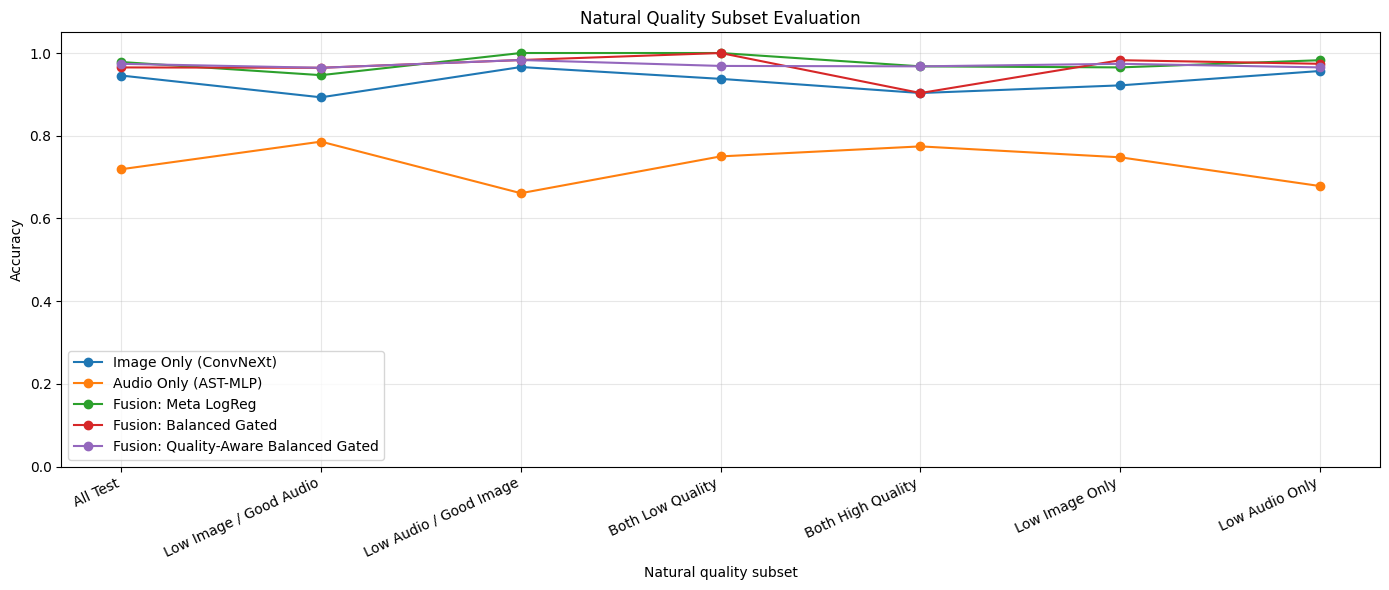

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/natural_quality_subset_main_systems.png


In [ ]:
systems_to_plot = [
    "Image Only (ConvNeXt)",
    "Audio Only (AST-MLP)",
    "Fusion: Meta LogReg",
    "Fusion: Balanced Gated",
    "Fusion: Quality-Aware Balanced Gated"
]

plot_df = quality_eval_df[
    quality_eval_df["System"].isin(systems_to_plot)
].copy()

plot_df["Subset"] = pd.Categorical(
    plot_df["Subset"],
    categories=subset_order,
    ordered=True
)

plot_df = plot_df.sort_values("Subset")

plt.figure(figsize=(14, 6))

for system in systems_to_plot:
    sub = plot_df[plot_df["System"] == system]
    plt.plot(sub["Subset"], sub["Accuracy"], marker="o", label=system)

plt.xticks(rotation=25, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Natural quality subset")
plt.title("Natural Quality Subset Evaluation")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

out_plot = os.path.join(OUT_Q_DIR, "natural_quality_subset_main_systems.png")
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

# Cell 8 — Show where QA-balanced helps

In [ ]:
help_rows = []

for subset_name, idx in quality_subsets.items():
    if len(idx) == 0:
        continue

    help_rows.append({
        "Subset": subset_name,
        "N": len(idx),

        "ImageWrong_QABalCorrect": int(np.sum(
            (img_pred[idx] != y_te[idx]) &
            (qa_bal_pred[idx] == y_te[idx])
        )),

        "AudioWrong_QABalCorrect": int(np.sum(
            (aud_pred[idx] != y_te[idx]) &
            (qa_bal_pred[idx] == y_te[idx])
        )),

        "BothUnimodalWrong_QABalCorrect": int(np.sum(
            (img_pred[idx] != y_te[idx]) &
            (aud_pred[idx] != y_te[idx]) &
            (qa_bal_pred[idx] == y_te[idx])
        )),

        "QABalCorrect_ImageWrong_AudioCorrect": int(np.sum(
            (img_pred[idx] != y_te[idx]) &
            (aud_pred[idx] == y_te[idx]) &
            (qa_bal_pred[idx] == y_te[idx])
        )),

        "QABalCorrect_ImageCorrect_AudioWrong": int(np.sum(
            (img_pred[idx] == y_te[idx]) &
            (aud_pred[idx] != y_te[idx]) &
            (qa_bal_pred[idx] == y_te[idx])
        )),

        "QABalAccuracy": float(np.mean(qa_bal_pred[idx] == y_te[idx])),
        "ImageAccuracy": float(np.mean(img_pred[idx] == y_te[idx])),
        "AudioAccuracy": float(np.mean(aud_pred[idx] == y_te[idx])),
        "MeanQABalAlpha": float(np.mean(qa_bal_alpha[idx])),
        "MeanImageQuality": float(np.mean(img_q[idx])),
        "MeanAudioQuality": float(np.mean(aud_q[idx])),
    })

help_df = pd.DataFrame(help_rows)

display(help_df)

help_df.to_csv(
    os.path.join(OUT_Q_DIR, "natural_quality_subset_qabal_help_cases.csv"),
    index=False
)

,Subset,N,ImageWrong_QABalCorrect,AudioWrong_QABalCorrect,BothUnimodalWrong_QABalCorrect,QABalCorrect_ImageWrong_AudioCorrect,QABalCorrect_ImageCorrect_AudioWrong,QABalAccuracy,ImageAccuracy,AudioAccuracy,MeanQABalAlpha,MeanImageQuality,MeanAudioQuality
0,All Test,459,17,128,4,13,124,0.973856,0.945534,0.718954,0.525230,0.043917,0.490223
1,Low Image / Good Audio,56,4,12,1,3,11,0.964286,0.892857,0.785714,0.533730,0.007040,0.653722
2,Low Audio / Good Image,59,1,20,0,1,20,0.983051,0.966102,0.661017,0.514713,0.074820,0.268166
3,Both Low Quality,32,1,8,0,1,8,0.968750,0.937500,0.750000,0.529895,0.007327,0.274356
4,Both High Quality,31,2,7,0,2,7,0.967742,0.903226,0.774194,0.525073,0.117550,0.752912
5,Low Image Only,115,6,29,1,5,28,0.973913,0.921739,0.747826,0.526846,0.007223,0.484161
6,Low Audio Only,115,2,37,0,2,37,0.965217,0.956522,0.678261,0.520562,0.044432,0.266037


# Cell 9 — Help-case plot

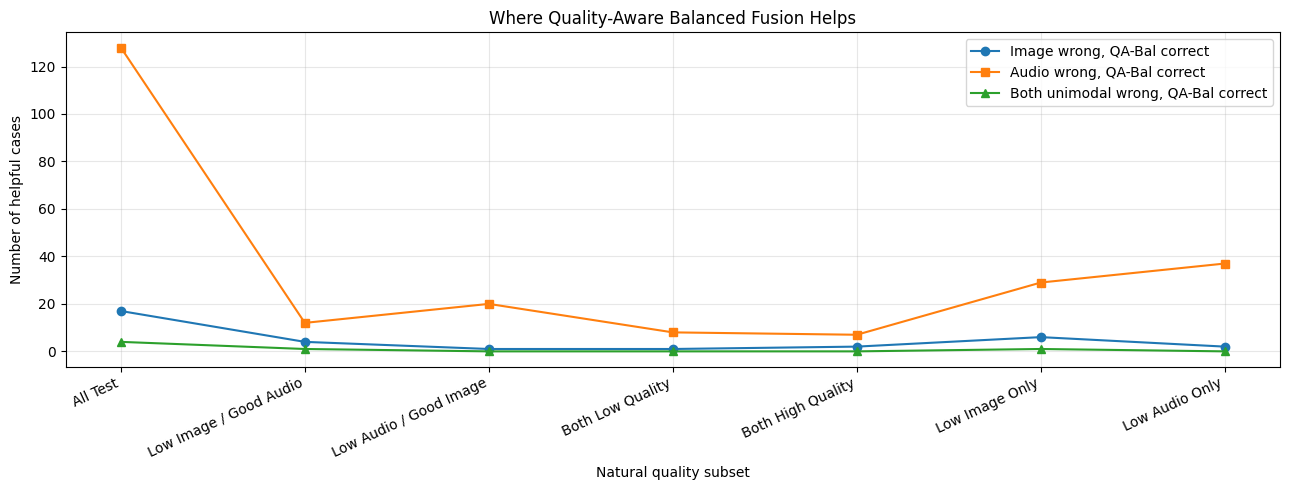

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/natural_quality_subset_qabal_help_cases.png


In [ ]:
help_plot_df = help_df[help_df["Subset"].isin(subset_order)].copy()
help_plot_df["Subset"] = pd.Categorical(
    help_plot_df["Subset"],
    categories=subset_order,
    ordered=True
)
help_plot_df = help_plot_df.sort_values("Subset")

plt.figure(figsize=(13, 5))

plt.plot(
    help_plot_df["Subset"],
    help_plot_df["ImageWrong_QABalCorrect"],
    marker="o",
    label="Image wrong, QA-Bal correct"
)

plt.plot(
    help_plot_df["Subset"],
    help_plot_df["AudioWrong_QABalCorrect"],
    marker="s",
    label="Audio wrong, QA-Bal correct"
)

plt.plot(
    help_plot_df["Subset"],
    help_plot_df["BothUnimodalWrong_QABalCorrect"],
    marker="^",
    label="Both unimodal wrong, QA-Bal correct"
)

plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of helpful cases")
plt.xlabel("Natural quality subset")
plt.title("Where Quality-Aware Balanced Fusion Helps")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

out_plot = os.path.join(OUT_Q_DIR, "natural_quality_subset_qabal_help_cases.png")
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

# Cell 10 — Gate behavior across natural quality subsets

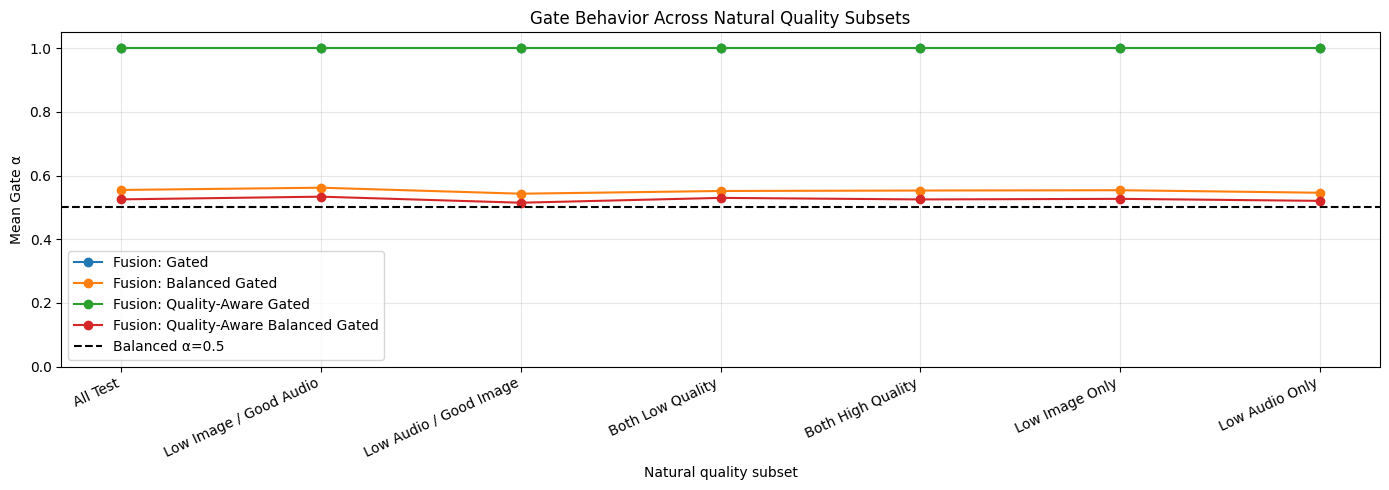

Saved: /content/drive/MyDrive/xenocanto/outputs_thesis_full/reports/natural_quality_subset_evaluation/natural_quality_subset_gate_behavior.png


In [ ]:
gate_subset_df = quality_eval_df[
    quality_eval_df["System"].isin([
        "Fusion: Gated",
        "Fusion: Balanced Gated",
        "Fusion: Quality-Aware Gated",
        "Fusion: Quality-Aware Balanced Gated"
    ])
].copy()

gate_subset_df["Subset"] = pd.Categorical(
    gate_subset_df["Subset"],
    categories=subset_order,
    ordered=True
)

gate_subset_df = gate_subset_df.sort_values("Subset")

plt.figure(figsize=(14, 5))

for system in gate_subset_df["System"].unique():
    sub = gate_subset_df[gate_subset_df["System"] == system]
    plt.plot(sub["Subset"], sub["MeanGateAlpha"], marker="o", label=system)

plt.axhline(0.5, color="black", linestyle="--", label="Balanced α=0.5")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean Gate α")
plt.xlabel("Natural quality subset")
plt.title("Gate Behavior Across Natural Quality Subsets")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

out_plot = os.path.join(OUT_Q_DIR, "natural_quality_subset_gate_behavior.png")
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

In [ ]:
# Paper stamnent

Although meta-classifier fusion achieves higher peak accuracy, it operates as a black-box without explicit control over modality contribution.
These are trained on SAME distribution
👉 They exploit:
logits
embeddings
patterns
👉 They are basically:
“stacking classifiers”




 In contrast, the proposed quality-aware balanced gating provides interpretable and adaptive modality weighting, while still achieving strong performance gains over unimodal systems under varying quality conditions.

#prove our model behaaves intelligntly (chk gate behaviour analysis cell)
Quality-aware gating improves over unimodal models under modality degradation.Balanced QA avoids collapse of standard QA gating.
Compare:

QA gated = 0.928 (Low image/good audio)
QA balanced = 0.964 ---> improved

Proposed method provides interpretable modality weighting

Meta models  cannot show:

alpha (image weight)

But we can:

MeanGateAlpha